In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_parquet("../data/merged/winsor_dataset.parquet")

a) Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.

In [8]:
loan_count=df['loan_status'].value_counts()
print(loan_count)

loan_status
0    1922444
1      77556
Name: count, dtype: int64


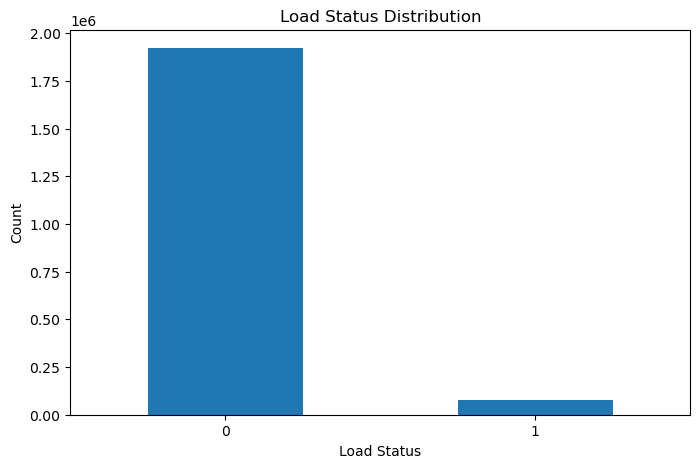

In [9]:
plt.figure(figsize=(8,5))
loan_count.plot(kind="bar")

plt.title('Load Status Distribution')
plt.xlabel('Load Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

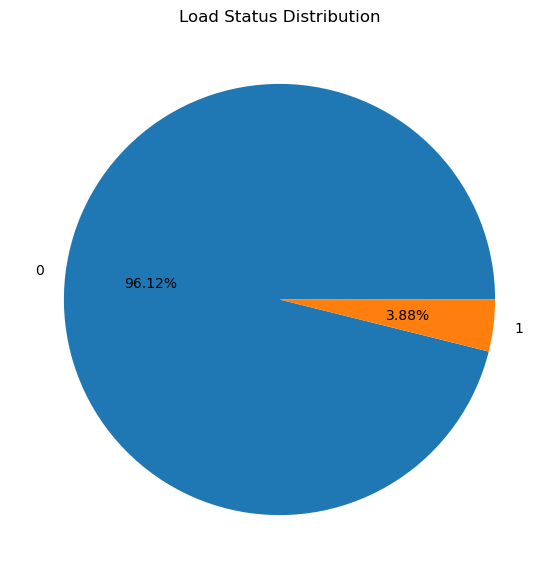

In [10]:
plt.figure(figsize=(7,7))

loan_count.plot(
    kind="pie",
    autopct="%1.2f%%"
)
plt.ylabel("")
plt.title('Load Status Distribution')
plt.show()

In [11]:
# Assuming : 0 = Non-default, 1 = Default
default_rate=(df['loan_status'].mean()*100)
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 3.88%


In [12]:
# Degree of Class Imbalance
df['loan_status'].value_counts(normalize=True)*100

loan_status
0    96.1222
1     3.8778
Name: proportion, dtype: float64

KDE Curve - A Kernel Density Estimation (KDE) curve is a smooth, continuous line used to represent the probability distribution of a dataset


In [14]:
# loan_status=1 -> Defaulted
# loan_status=0 -> Performing
defaulted=df.loc[df['loan_status']==1,'cibil_score']
performing=df.loc[df['loan_status']==0,'cibil_score']

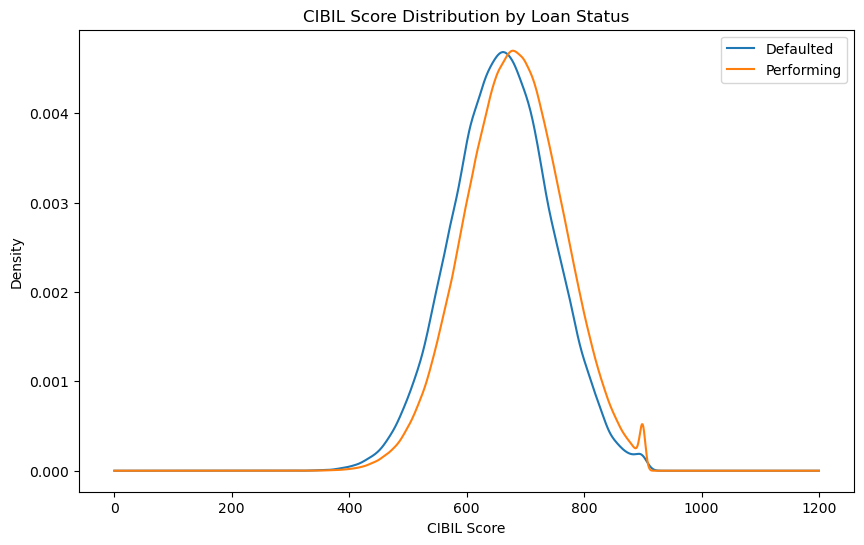

In [15]:
plt.figure(figsize=(10,6))
defaulted.plot.kde(label='Defaulted')
performing.plot.kde(label='Performing')

plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.title('CIBIL Score Distribution by Loan Status')
plt.legend()
plt.show()

In [16]:
mean_default = defaulted.mean()
mean_performing = performing.mean()

print("Defaulted Mean:", round(mean_default,2))
print("Performing Mean:", round(mean_performing,2))

Defaulted Mean: 660.11
Performing Mean: 680.68


Cohen's d measures how far apart the two distributions are.

In [ ]:

n1 = len(defaulted)
n2 = len(performing)

s1 = defaulted.std()
s2 = performing.std()

# weighted average of the standard deviations from two independent groups (\(defaulted\) and \(performing\)). 
pooled_std = np.sqrt(
    ((n1-1)*s1**2 + (n2-1)*s2**2)
    /
    (n1+n2-2) # dof
)

# calculates how many standard deviations separate the means of your two groups. 

cohens_d = (
    mean_performing - mean_default
) / pooled_std # as a standard unit of measurement to scale that distance.

print("Cohen's d =", round(cohens_d,3))

Cohen's d = 0.243


In [18]:
from scipy.stats import norm

overlap = 2 * norm.cdf(-abs(cohens_d)/2)

print("Distribution Overlap =", round(overlap*100,2), "%")

Distribution Overlap = 90.31 %


In [19]:
summary = pd.DataFrame({
    "Metric":[
        "Mean CIBIL (Defaulted)",
        "Mean CIBIL (Performing)",
        "Cohen's d",
        "Distribution Overlap (%)"
    ],
    "Value":[
        mean_default,
        mean_performing,
        cohens_d,
        overlap*100
    ]
})

summary.round(2)

,Metric,Value
0,Mean CIBIL (Defaulted),660.11
1,Mean CIBIL (Performing),680.68
2,Cohen's d,0.24
3,Distribution Overlap (%),90.31


In [21]:
df['loan_status'].value_counts()

loan_status
0    1922444
1      77556
Name: count, dtype: int64

### 12-panel histogram grid covering all numeric features.

In [29]:
df.columns
inr_col=[]
for col in df.columns:
    if 'inr' in col:
        inr_col.append(col)
inr_col

['loan_amnt_inr',
 'funded_amnt_inr',
 'installment_inr',
 'annual_installment_inr',
 'annual_inc_inr',
 'revol_bal_inr',
 'total_rev_hi_lim_inr',
 'avg_cur_bal_inr',
 'recoveries_inr',
 'hardship_amount_inr',
 'net_loss_inr',
 'provision_inr',
 'total_pymnt_inr',
 'total_pymnt_inv_inr',
 'total_rec_prncp_inr',
 'total_rec_int_inr',
 'last_pymnt_amnt_inr',
 'out_prncp_inr',
 'out_prncp_inv_inr',
 'expected_loss_inr',
 'state_per_capita_inc_inr',
 'installment_due_inr',
 'total_emi_due_inr',
 'total_emi_paid_inr',
 'emi_overdue_inr',
 'emi_advance_paid_inr',
 'penal_charges_inr',
 'waiver_amount_inr',
 'sanctioned_amount_inr',
 'disbursed_amount_inr',
 'total_cc_limit_inr',
 'total_cc_balance_inr',
 'cash_advance_inr',
 'cc_spend_last3m_inr',
 'avg_monthly_cc_spend_inr',
 'collateral_value_inr',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr']

In [ ]:
# choosing a representative set of important variables.
hist_cols = [
    'loan_amnt_inr',
    'annual_inc_inr',
    'cibil_score',
    'dti_pct',
    'revol_bal_inr',
    'avg_cur_bal_inr',
    'total_rev_hi_lim_inr',
    'recoveries_inr',
    'expected_loss_inr',
    'cash_advance_inr',
    'cc_spend_last3m_inr',
    'avg_monthly_cc_spend_inr'
]

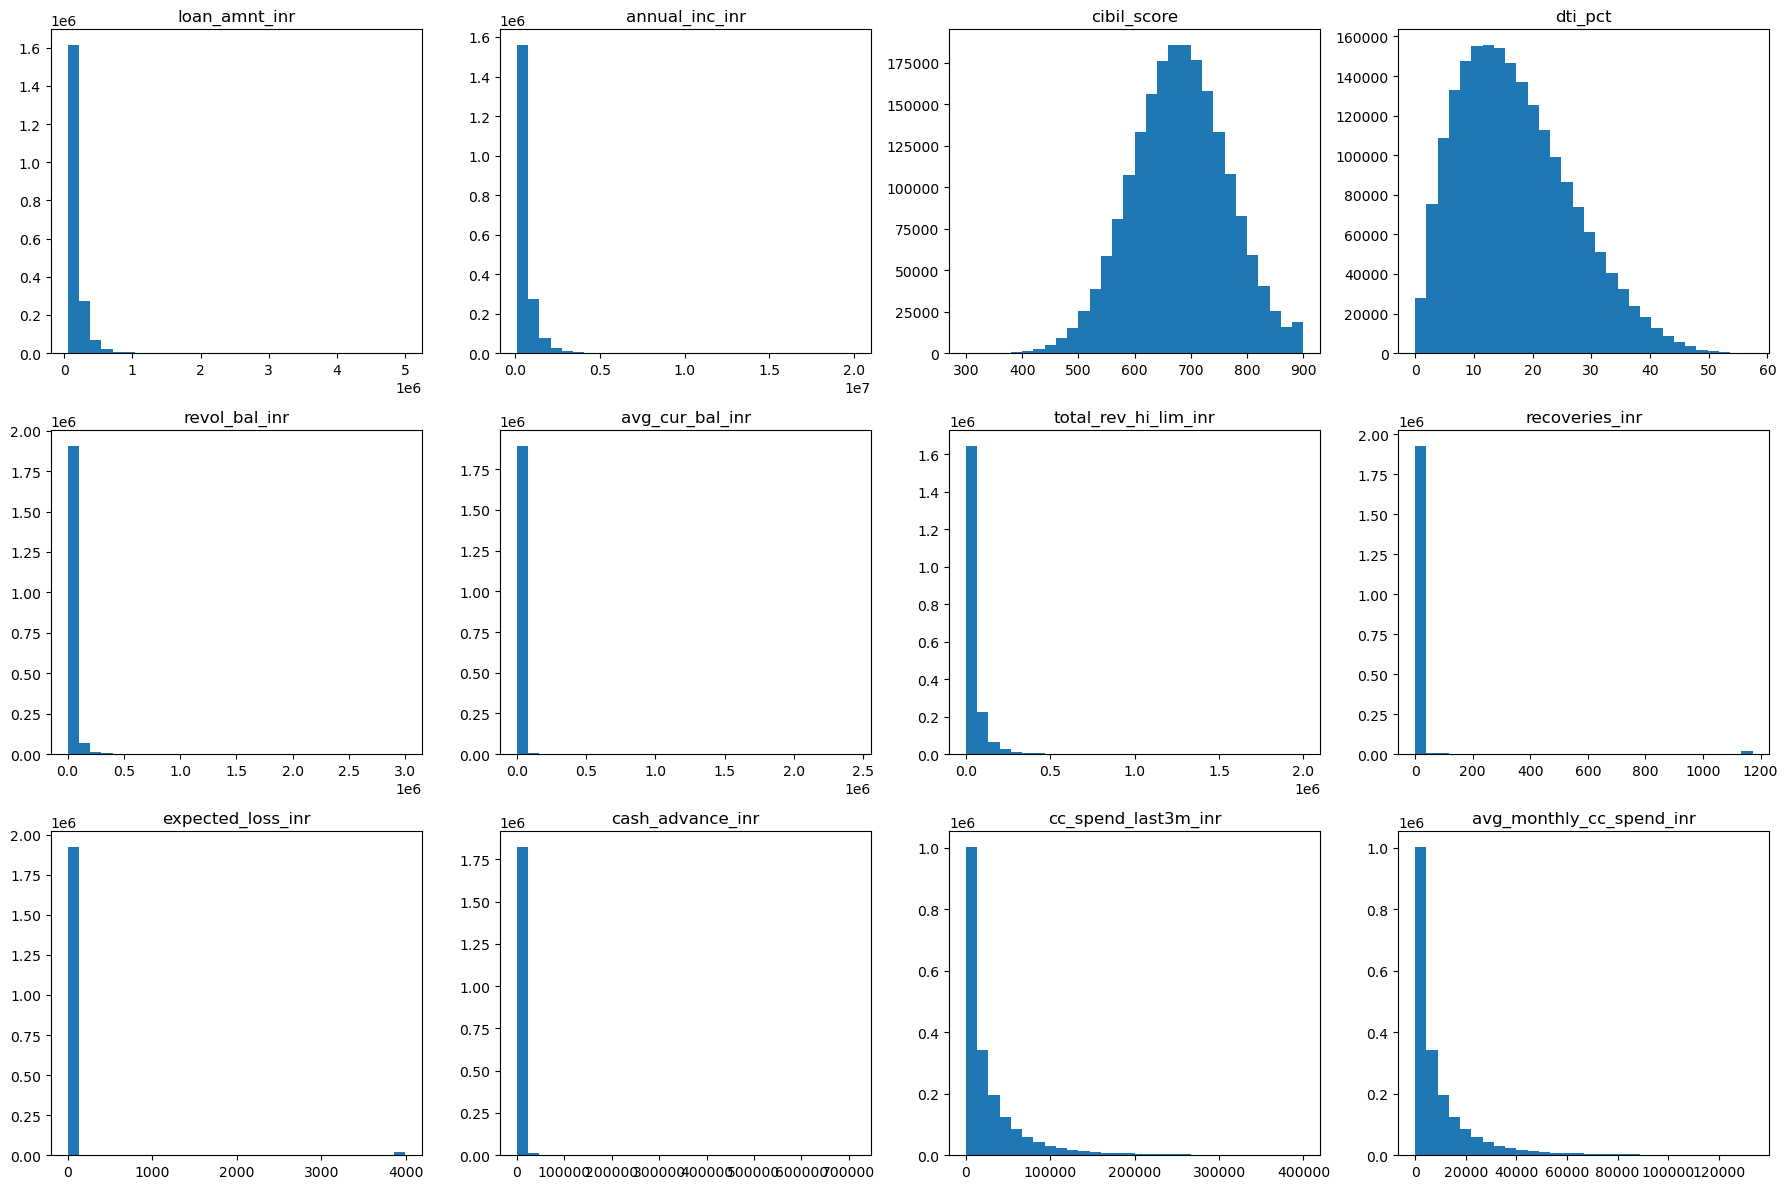

In [ ]:
# fig - entire window
# axes - 2D array matrix
fig, axes = plt.subplots(
    3,
    4,
    figsize=(18,12) # dimension
)
axes = axes.flatten() # 2D array of subplots into a simple 1D array

for i,col in enumerate(hist_cols):
    # Dividing the range of data values into 30 equal intervals (bars) and counting how many data points fall into each interval to generate the plot.
    # "How are the values distributed?"
    axes[i].hist(df[col].dropna(),bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [36]:
skew_df=(df[hist_cols].skew().sort_values(ascending=False))
print(skew_df)

avg_cur_bal_inr             25.655979
cash_advance_inr            18.744984
revol_bal_inr                9.610805
total_rev_hi_lim_inr         7.499483
recoveries_inr               7.164084
expected_loss_inr            6.649011
annual_inc_inr               4.675825
loan_amnt_inr                3.651117
avg_monthly_cc_spend_inr     3.234998
cc_spend_last3m_inr          3.234997
dti_pct                      0.597136
cibil_score                 -0.034678
dtype: float64


In [37]:
high_skew = skew_df[skew_df > 2]

print(high_skew)

avg_cur_bal_inr             25.655979
cash_advance_inr            18.744984
revol_bal_inr                9.610805
total_rev_hi_lim_inr         7.499483
recoveries_inr               7.164084
expected_loss_inr            6.649011
annual_inc_inr               4.675825
loan_amnt_inr                3.651117
avg_monthly_cc_spend_inr     3.234998
cc_spend_last3m_inr          3.234997
dtype: float64


In [38]:
for col in high_skew.index:

    df[col + '_log'] = np.log1p(
        df[col]
    )

In [39]:
comparison = pd.DataFrame({
    'before_skew':
        df[high_skew.index].skew()
})

In [41]:
comparison['after_skew'] = [
    df[col+'_log'].skew()
    for col in high_skew.index
]

comparison = comparison.round(3)
comparison

,before_skew,after_skew
avg_cur_bal_inr,25.656,0.234
cash_advance_inr,18.745,1.479
revol_bal_inr,9.611,0.000
total_rev_hi_lim_inr,7.499,-0.001
recoveries_inr,7.164,5.041
expected_loss_inr,6.649,4.885
annual_inc_inr,4.676,0.329
loan_amnt_inr,3.651,0.582
avg_monthly_cc_spend_inr,3.235,-0.814
cc_spend_last3m_inr,3.235,-0.846


In [4]:
num_cols=df.select_dtypes(include='number').columns

In [5]:
top20=(
    df[num_cols].var().sort_values(ascending=False).head(20).index
)

In [6]:
corr_matrix=df[top20].corr(method='pearson')
corr_matrix.head()

,collateral_value_inr,prop_value_inr,annual_inc_inr,business_asset_val_inr,total_cc_limit_inr,total_emi_due_inr,total_pymnt_inr,total_emi_paid_inr,total_pymnt_inv_inr,loan_amnt_inr,total_rec_prncp_inr,funded_amnt_inr,sanctioned_amount_inr,disbursed_amount_inr,state_per_capita_inc_inr,vehicle_value_inr,total_rev_hi_lim_inr,total_cc_balance_inr,annual_installment_inr,total_rec_int_inr
collateral_value_inr,1.000000,0.971581,0.000171,0.145080,0.000743,-0.000048,-0.000085,-0.000027,-0.000094,0.000106,0.000037,0.000073,0.000118,0.000126,-0.001317,-0.013516,-0.000579,-0.000272,0.000917,-0.000401
prop_value_inr,0.971581,1.000000,-0.000026,-0.080574,0.000539,-0.000099,-0.000158,-0.000101,-0.000167,0.000085,-0.000008,0.000067,0.000088,0.000094,-0.001041,-0.078878,-0.000666,-0.000428,0.001061,-0.000537
annual_inc_inr,0.000171,-0.000026,1.000000,0.000480,0.625627,-0.000070,0.000463,0.000349,0.000458,-0.000117,0.000330,-0.000156,-0.000018,-0.000018,-0.001474,0.001127,0.000781,0.521497,-0.000804,0.000742
business_asset_val_inr,0.145080,-0.080574,0.000480,1.000000,0.000570,0.000233,0.000335,0.000354,0.000334,0.000106,0.000215,0.000045,0.000102,0.000115,-0.001266,-0.050380,0.000248,0.000660,-0.000574,0.000599
total_cc_limit_inr,0.000743,0.000539,0.625627,0.000570,1.000000,0.000589,0.000959,0.000771,0.000980,0.000632,0.000925,0.000619,0.000612,0.000631,-0.001074,0.000985,0.000536,0.834587,0.000448,0.000887


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

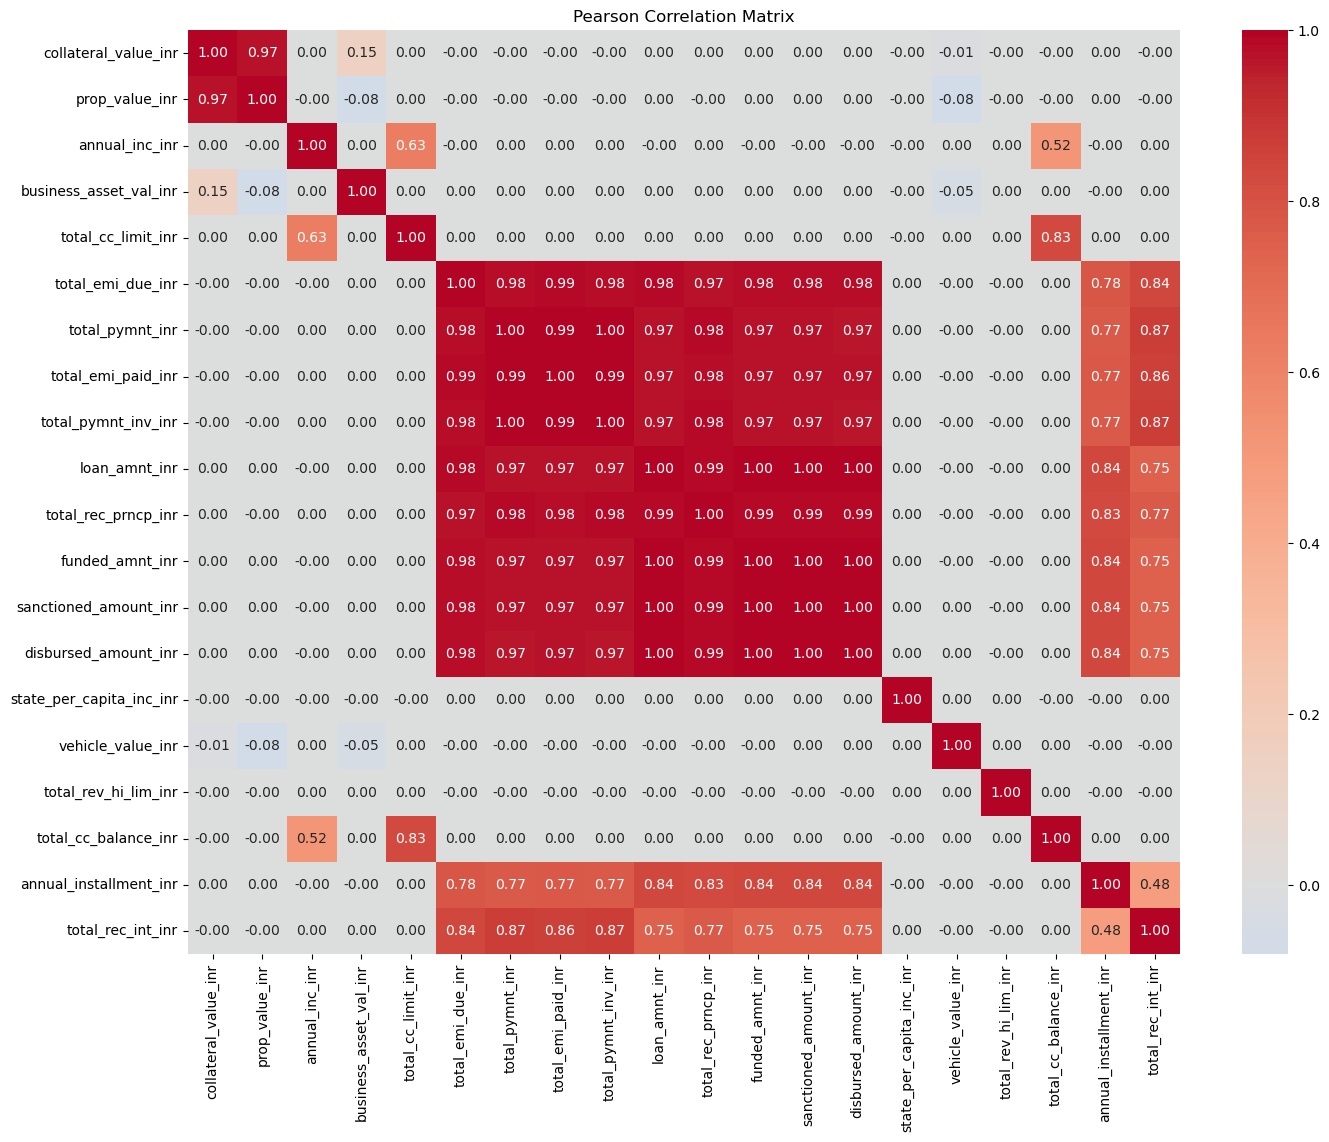

In [8]:
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Pearson Correlation Matrix')
plt.show()

In [9]:
corr_pairs=corr_matrix.abs()
high_corr=[]
for i in range(len(corr_pairs.columns)):
    for j in range(i+1,len(corr_pairs.columns)):
        corr_value=corr_pairs.iloc[i,j]
        if corr_value>0.75:
            high_corr.append([
                corr_pairs.index[i],
                corr_pairs.columns[j],
                round(corr_value,3)
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Feature_1','Feature_2','Correlation']
)

high_corr_df.sort_values(
    by='Correlation',
    ascending=False
)

,Feature_1,Feature_2,Correlation
13,total_pymnt_inr,total_pymnt_inv_inr,1.000
49,sanctioned_amount_inr,disbursed_amount_inr,0.999
37,loan_amnt_inr,funded_amnt_inr,0.998
38,loan_amnt_inr,sanctioned_amount_inr,0.998
39,loan_amnt_inr,disbursed_amount_inr,0.997
46,funded_amnt_inr,sanctioned_amount_inr,0.996
47,funded_amnt_inr,disbursed_amount_inr,0.995
12,total_pymnt_inr,total_emi_paid_inr,0.994
21,total_emi_paid_inr,total_pymnt_inv_inr,0.993
36,loan_amnt_inr,total_rec_prncp_inr,0.988
